<a href="https://colab.research.google.com/github/zain4cs/DecodeLab_Intern/blob/main/intern_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Datasets/house_prices.csv")
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  object 
 2   Description        184508 non-null  object 
 3   Amount(in rupees)  187531 non-null  object 
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  object 
 6   Carpet Area        106858 non-null  object 
 7   Status             186916 non-null  object 
 8   Floor              180454 non-null  object 
 9   Transaction        187448 non-null  object 
 10  Furnishing         184634 non-null  object 
 11  facing             117298 non-null  object 
 12  overlooking        106095 non-null  object 
 13  Society            77853 non-null   object 
 14  Bathroom           186703 non-null  object 
 15  Balcony            138596 non-null  object 
 16  Ca

In [ ]:
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_pct = missing_pct.sort_values(ascending=False)
print(missing_pct)

Plot Area            100.000000
Dimensions           100.000000
Society               58.485264
Super Area            57.422506
Car Parking           55.114621
overlooking           43.425354
Carpet Area           43.018488
facing                37.451408
Ownership             34.936624
Balcony               26.094352
Price (in rupees)      9.419776
Floor                  3.773776
Description            1.612000
Furnishing             1.544811
Bathroom               0.441527
Status                 0.327946
Transaction            0.044259
Amount(in rupees)      0.000000
Title                  0.000000
Index                  0.000000
location               0.000000
dtype: float64


_____________________

**Handle Missing Values**

**5% missing:** Delete Row(Dropna)

**5%-20% missing:**  Use median (fillna)

**> 20% missing:** Unknown

**100% missing:**  Remove Column

In [ ]:
df.columns

Index(['Index', 'Title', 'Description', 'Amount(in rupees)',
       'Price (in rupees)', 'location', 'Carpet Area', 'Status', 'Floor',
       'Transaction', 'Furnishing', 'facing', 'overlooking', 'Society',
       'Bathroom', 'Balcony', 'Car Parking', 'Ownership', 'Super Area',
       'Dimensions', 'Plot Area'],
      dtype='object')

In [ ]:
# 100% Missing Value's

df = df.drop(columns=['Dimensions', 'Plot Area'])
print("New Sahpe: ", df.shape)

New Sahpe:  (187531, 19)


In [ ]:
#  < 5% Missing

low_missing = ['Description', 'Status', 'Floor', 'Bathroom', 'Transaction','Furnishing']
df = df.dropna(subset=low_missing)
print("New Sahpe", df.shape)

New Sahpe (175813, 19)


In [ ]:
# (9% missing)
price_median = df['Price (in rupees)'].median()
print("Median Price", price_median)

Median Price 6034.0


In [ ]:
df['Price (in rupees)'] = df['Price (in rupees)'].fillna(price_median)

print("missing Values:", df["Price (in rupees)"].isnull().sum())

missing Values: 0


In [ ]:
# 20% Missing Columns

high_missing = ["Carpet Area", "facing", "overlooking", "Society",
                "Balcony", "Car Parking", "Ownership", "Super Area"]

for col in high_missing:
    df[col] = df[col].fillna("Unknown")


print(df[high_missing].isnull().sum())

Carpet Area    0
facing         0
overlooking    0
Society        0
Balcony        0
Car Parking    0
Ownership      0
Super Area     0
dtype: int64


In [ ]:
print(df.isnull().sum())

Index                0
Title                0
Description          0
Amount(in rupees)    0
Price (in rupees)    0
location             0
Carpet Area          0
Status               0
Floor                0
Transaction          0
Furnishing           0
facing               0
overlooking          0
Society              0
Bathroom             0
Balcony              0
Car Parking          0
Ownership            0
Super Area           0
dtype: int64


_____________________

**Detect Outliers**

**IQR Method (Interquartile Range)**

In [ ]:
Q1 = df["Price (in rupees)"].quantile(0.25)
Q3 = df["Price (in rupees)"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df["Price (in rupees)"] < lower_bound) | (df["Price (in rupees)"] > upper_bound)]
print("Kitne Outliers Hain:", len(outliers))

Q1: 4500.0
Q3: 8410.0
IQR: 3910.0
Lower Bound: -1365.0
Upper Bound: 14275.0
Kitne Outliers Hain: 9881


In [ ]:
df["Price (in rupees)"] = np.clip(df["Price (in rupees)"], lower_bound, upper_bound)

print("Price ka naya minimum:", df["Price (in rupees)"].min())
print("Price ka naya maximum:", df["Price (in rupees)"].max())

Price ka naya minimum: 0.0
Price ka naya maximum: 14275.0


__________________

**Create New Features**

In [ ]:
# Feature 1: Price_Category (Low / Medium / High)

low_limit = df["Price (in rupees)"].quantile(0.33)
high_limit = df["Price (in rupees)"].quantile(0.66)

def price_category(price):
    if price <= low_limit:
        return "Low"
    elif price <= high_limit:
        return "Medium"
    else:
        return "High"

df["Price_Category"] = df["Price (in rupees)"].apply(price_category)

print("Feature 1 ready: Price_Category")
print(df["Price_Category"].value_counts())

Feature 1 ready: Price_Category
Price_Category
High      59548
Medium    58199
Low       58066
Name: count, dtype: int64


In [ ]:
# Feature 2: Has_Parking (0 or 1)

df["Has_Parking"] = df["Car Parking"].apply(lambda x: 0 if x == "Unknown" else 1)

print("Feature 2 ready: Has_Parking")
print(df["Has_Parking"].value_counts())

Feature 2 ready: Has_Parking
Has_Parking
0    96454
1    79359
Name: count, dtype: int64


In [ ]:
# Feature 3: Is_Furnished (0 or 1)

df["Is_Furnished"] = df["Furnishing"].apply(lambda x: 1 if x == "Furnished" else 0)

print("Feature 3 ready: Is_Furnished")
print(df["Is_Furnished"].value_counts())

Feature 3 ready: Is_Furnished
Is_Furnished
0    156159
1     19654
Name: count, dtype: int64


In [ ]:
print("3 Featrues")
print(df[["Price_Category", "Has_Parking", "Is_Furnished"]].head(10))

3 Featrues
  Price_Category  Has_Parking  Is_Furnished
0         Medium            0             0
1           High            1             0
2           High            1             0
3         Medium            0             0
4           High            1             0
5         Medium            0             0
6            Low            0             0
7           High            0             1
8           High            0             1
9           High            1             0


________________

**KNN**

In [ ]:
from sklearn.impute import KNNImputer

In [ ]:
df_sample = df.sample(10000, random_state=42).reset_index(drop=True)

df_sample["Carpet_sqft"] = df_sample["Carpet Area"].str.replace("sqft", "").str.strip()
df_sample["Carpet_sqft"] = pd.to_numeric(df_sample["Carpet_sqft"], errors="coerce")

print("Before KNN:", df_sample["Carpet_sqft"].isnull().sum())

Before KNN: 4474


In [ ]:
knn = KNNImputer(n_neighbors=5)
df_sample[["Carpet_sqft"]] = knn.fit_transform(df_sample[["Carpet_sqft"]])

print("After KNN:", df_sample["Carpet_sqft"].isnull().sum())

After KNN: 0


_________________

**One-Hot Encoding**

Categorical columns convert into numbers

In [ ]:
df = pd.get_dummies(df, columns=["Furnishing", "Transaction"], drop_first=True)

print("New shape:", df.shape)

New shape: (175813, 24)


In [ ]:
df.to_csv("house_prices_cleaned.csv", index=False)

print("Saved")
print("Final shape:", df.shape)

Saved
Final shape: (175813, 24)


____________________

**Visualization**

In [ ]:
import matplotlib.pyplot as plt

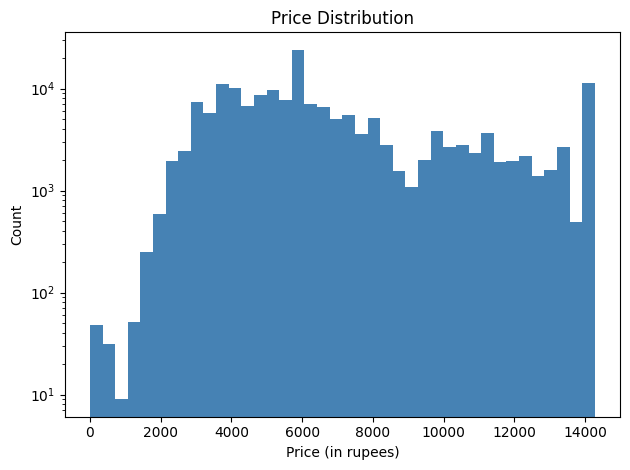

In [ ]:
plt.hist(df['Price (in rupees)'], bins=40, color='steelblue')
plt.title('Price Distribution')
plt.xlabel('Price (in rupees)')
plt.ylabel('Count')
plt.yscale('log')
plt.tight_layout()
plt.savefig('graph2_price.png', dpi=150)
plt.show()